# Assets with Risky Returns: Portfolio Choice


In [10]:
# Initial notebook setup
import numpy as np
import matplotlib.pyplot as plt

# import the agent type
from HARK.ConsumptionSaving.ConsPortfolioModel import (
    PortfolioConsumerType,
    init_portfolio,
)

# import functions for calculating share limit and creating risky asset distribution
from HARK.Calibration.Assets.AssetProcesses import (
    calc_ShareLimit_for_CRRA,
    make_lognormal_RiskyDstn
)

from ipywidgets import FloatSlider, interact, fixed

# import plotting utilities
from HARK.utilities import plot_funcs, plot_funcs_der

In [2]:
# Use default parameters that are built into the AgentType subclass
PortfolioTypeExample = PortfolioConsumerType()
PortfolioTypeExample.cycles = 0

# Solve the Portfolio Choice Model
PortfolioTypeExample.solve()

PortfolioTypeExample.unpack("cFuncAdj")
PortfolioTypeExample.unpack("ShareFuncAdj")

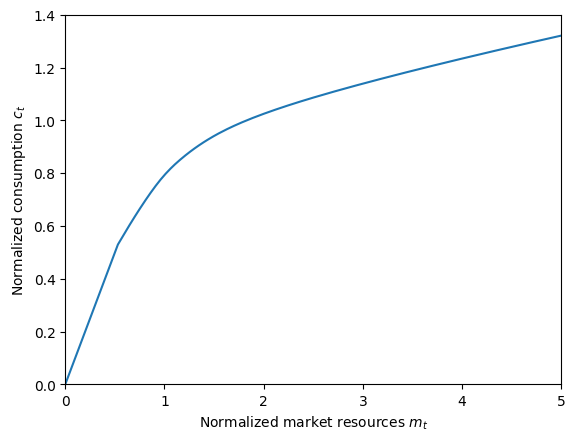

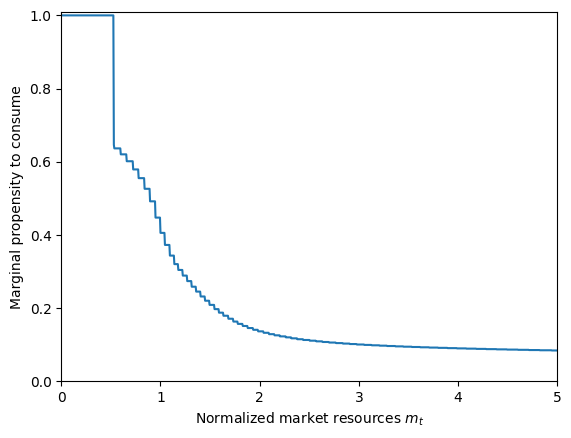

In [3]:
# Plot the consumption function and MPC for the portfolio choice consumer
plt.xlabel(r"Normalized market resources $m_t$")
plt.ylabel(r"Normalized consumption $c_t$")
plt.ylim(0.0, 1.4)
plot_funcs(PortfolioTypeExample.cFuncAdj, 0.0, 5.0)
plt.xlabel(r"Normalized market resources $m_t$")
plt.ylabel(r"Marginal propensity to consume")
plt.ylim(0.0, 1.01)
plot_funcs_der(PortfolioTypeExample.cFuncAdj, 0.0, 5.0)

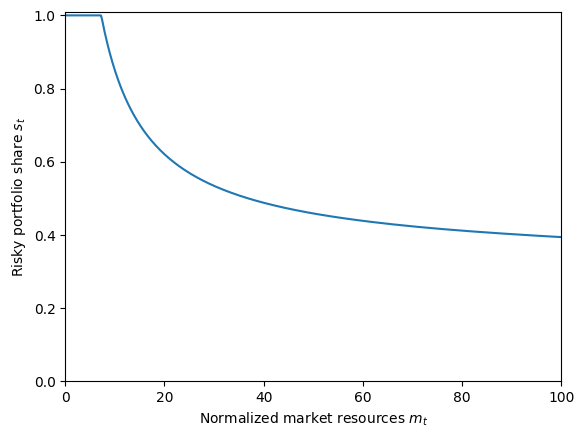

In [4]:
# Plot the share of resources invested in the risky asset
plt.xlabel(r"Normalized market resources $m_t$")
plt.ylabel(r"Risky portfolio share $s_t$")
plt.ylim(0.0, 1.01)
plot_funcs(PortfolioTypeExample.ShareFuncAdj, 0.0, 100.0)

## Portfolio choice with Merton-Samuelson limiting shares

The code below tests the mathematical limits of the model for a Merton-Samuelson consumer.

In [5]:
# Adjust Risky asset for this example
Rfree = 1.02               # Risk-free return factor
RiskyAvg = 1.05            # Risky asset average return factor
RiskyStd = 0.2             # Risky asset standard deviation
RiskyCount = 10             # Number of points to use in discrete approximation

# Approximate the risky asset return distribution using equiprobable points
RiskyDstn = make_lognormal_RiskyDstn(1,
    RiskyAvg, RiskyStd, RiskyCount,PortfolioTypeExample.RNG
)
 
# Print the risky asset's discrete possible values
print("Equiprobable return factors:")
print(RiskyDstn.atoms[0])


Equiprobable return factors:
[0.72691319 0.83542024 0.89897097 0.95276441 1.00370425 1.05558636
 1.11205773 1.17870737 1.26875336 1.46712214]


### Campbell Viceira  Approximation

As shown in the [PortfolioCRRA lecture note](https://www.econ2.jhu.edu/people/ccarroll/public/lecturenotes/AssetPricing/Portfolio-CRRA/), 

The share of market resources spent on the risky asset can be approximated by 

$$
ς = \frac{φ}{ρσ_r^2}
$$

Where $φ$ is the "equity premium", $ρ$ is the coefficient of relative risk aversion, and $σ_r^2$ is the variance of the risky asset return. 


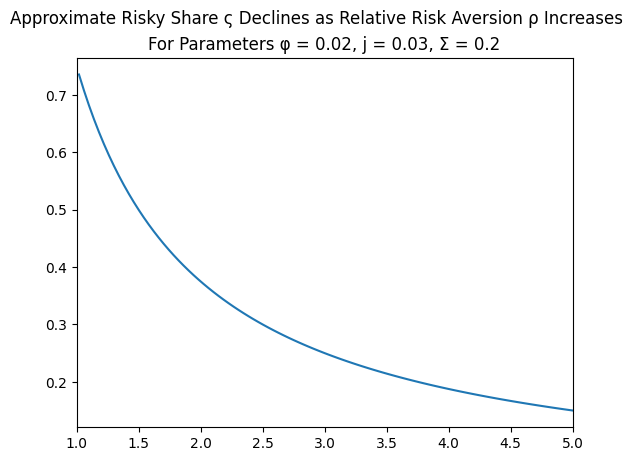

In [6]:
# Define the approximate Share limit function
RiskPremium = RiskyAvg - Rfree
ShareApprox = lambda c: RiskPremium / (c * RiskyStd**2)

# Loop across CRRA values 
CRRAarray = np.linspace(1.02,5.0,100)
SharelimitArray = []
SharelimitApprox = []

for c in CRRAarray:
    # Exact Share limit using HARK function
    SharelimitArray.append(calc_ShareLimit_for_CRRA(1,RiskyDstn,c,Rfree))
    # Approximate Share limit using formula
    SharelimitApprox.append(ShareApprox(c))

# Plot the results
plt.plot(CRRAarray, SharelimitApprox)
plt.xlim(1,5)
plt.suptitle("Approximate Risky Share ς Declines as Relative Risk Aversion ρ Increases")
plt.title("For Parameters φ = 0.02, j = 0.03, Σ = 0.2")
plt.show()


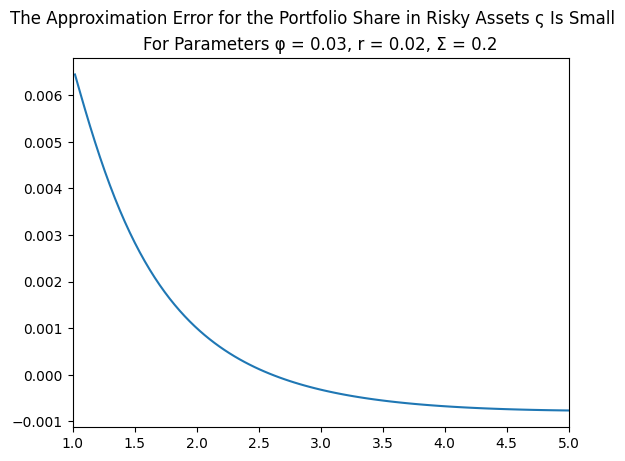

In [7]:
# calculate the approximation error
ApproxErrorArray = [a - b for a, b in zip(SharelimitArray, SharelimitApprox)]

# Plot the results
plt.plot(CRRAarray, ApproxErrorArray)
plt.suptitle("The Approximation Error for the Portfolio Share in Risky Assets ς Is Small")
plt.title("For Parameters φ = 0.03, r = 0.02, Σ = 0.2")
plt.xlim(1,5)
plt.show()

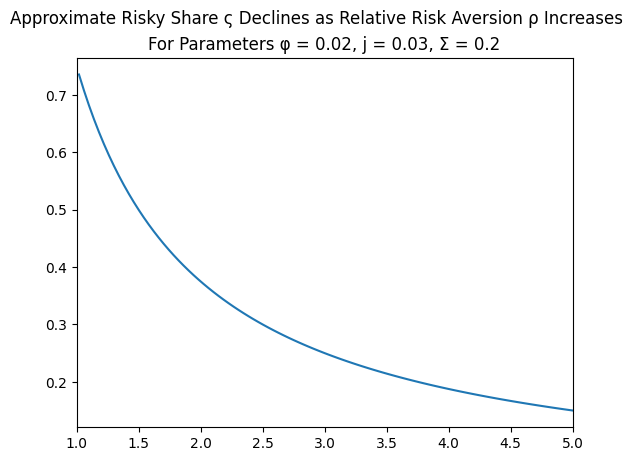

In [8]:
# Adjust Risky asset for this example
Rfree = 1.02               # Risk-free return factor
RiskyAvg = 1.05            # Risky asset average return factor
RiskyStd = 0.2             # Risky asset standard deviation
RiskyCount = 10             # Number of points to use in discrete approximation

# Create the risky asset return distribution
RiskyDstn = make_lognormal_RiskyDstn(1,
    RiskyAvg, RiskyStd, RiskyCount,PortfolioTypeExample.RNG
)


# Define the approximate Share limit function
RiskPremium = RiskyAvg - Rfree
ShareApprox = lambda c: RiskPremium / (c * RiskyStd**2)

# Loop across CRRA values 
CRRAarray = np.linspace(1.02,5.0,100)
SharelimitArray = []
SharelimitApprox = []

for c in CRRAarray:
    # Exact Share limit using HARK function
    SharelimitArray.append(calc_ShareLimit_for_CRRA(1,RiskyDstn,c,Rfree))
    # Approximate Share limit using formula
    SharelimitApprox.append(ShareApprox(c))

# Plot the results
plt.plot(CRRAarray, SharelimitApprox)
plt.xlim(1,5)
plt.suptitle("Approximate Risky Share ς Declines as Relative Risk Aversion ρ Increases")
plt.title("For Parameters φ = 0.02, j = 0.03, Σ = 0.2")
plt.show()


## Interactive Widget

In [11]:
def ApproxPlot(RiskPremium, RiskyStd):
    # Define the approximate Share limit function
    ShareApprox = lambda c: RiskPremium / (c * RiskyStd**2)
    # Loop across CRRA values 
    CRRAarray = np.linspace(1.02,5.0,100)
    SharelimitApprox = []

    for c in CRRAarray:
        # Approximate Share limit using formula
        SharelimitApprox.append(min(ShareApprox(c),1))

    # Plot the results
    plt.plot(CRRAarray, SharelimitApprox)
    plt.xlim(1,5)
    plt.ylim(0,1.2)
    plt.xlabel("Relative Risk Aversion ρ")
    plt.title("Approximate Risky Share ς")
    plt.show()


# Define some widgets to control the plot

# Define a risky asset return slider
RiskPremiumW = FloatSlider(
    min=0.0,
    max=0.2,
    step=0.01,
    value=0.03,
    continuous_update=True,
    readout_format=".2f",
    description="φ",
)

# Define a risky asset standard deviation slider
RiskyStdW = FloatSlider(
    min=0.02,
    max=0.5,
    step=0.02,
    value=0.2,
    continuous_update=True,
    readout_format=".2f",
    description="σ",
)

# Make the widget

interact(
    ApproxPlot,
    RiskPremium=RiskPremiumW,
    RiskyStd=RiskyStdW,
)

interactive(children=(FloatSlider(value=0.03, description='φ', max=0.2, step=0.01), FloatSlider(value=0.2, des…

<function __main__.ApproxPlot(RiskPremium, RiskyStd)>